# Band Filtering in a Tight-Binding Chain

This notebook applies a bounded polynomial filter to a one-dimensional tight-binding Hamiltonian. The real physics task is spectral band selection: keep states in a desired energy window while suppressing the rest.

This kind of filtering appears in condensed matter, transport, density-of-states estimation, and low-energy effective model construction.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a finite nearest-neighbor tight-binding chain.

**QSVT implementation.** It uses a smooth band-pass polynomial to select eigenmodes near a target energy window. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Direct eigensolver mode weights validate the filtered state. For large lattice Hamiltonians, a QSVT band filter can act on a block-encoded operator while avoiding full spectrum construction.


## Variable definitions

- `n_sites`: number of lattice sites in the finite chain.
- `H`: tight-binding Hamiltonian.
- `energies`, `modes`: eigenvalues and eigenvectors of `H`.
- `E_center`: target band-center energy.
- `scale`: spectral scale used to map `H` into the polynomial domain.
- `A`: rescaled Hamiltonian.
- `cutoff`, `sharpness`: parameters controlling the smooth band-pass filter.
- `reject_center_coeffs`, `band_pass_coeffs`: intermediate and final filter polynomial coefficients.
- `F_band`: polynomial band-pass operator.
- `scaled_energies`: eigenvalues after rescaling.
- `band_weights`: polynomial weights assigned to exact eigenmodes.
- `localized`, `filtered`: input localized state and filtered state.
- `initial_mode_weights`, `filtered_mode_weights`: spectral mode probabilities before and after filtering.
- `sites`, `xs`, `fig`, `axes`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.design import design_filter_polynomial
from qsvt.hamiltonians import tight_binding_chain
from qsvt.polynomials import eval_polynomial
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

## Build the chain Hamiltonian

For an open chain with nearest-neighbor hopping,

$$H = -t \sum_i (|i\rangle\langle i+1| + |i+1\rangle\langle i|).$$

In [2]:
n_sites = 8
H = tight_binding_chain(n_sites)
energies, modes = eigh_hermitian(H)

print(f"Energies [hopping units]: {energies}")

Energies [hopping units]: [-1.8794 -1.5321 -1.     -0.3473  0.3473  1.      1.5321  1.8794]


## Chain schematic

The band filter acts on a finite nearest-neighbor tight-binding chain.


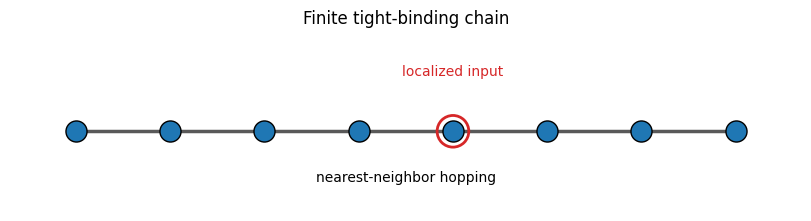

In [3]:
fig, ax = plt.subplots(figsize=(8.0, 2.1), constrained_layout=True)

sites = np.arange(n_sites)
for site in range(n_sites - 1):
    ax.plot([site, site + 1], [0, 0], color="0.35", linewidth=2.5, zorder=1)
ax.scatter(
    sites, np.zeros(n_sites), s=230, color="tab:blue", edgecolor="black", zorder=3
)
ax.scatter(
    n_sites // 2,
    0,
    s=520,
    facecolors="none",
    edgecolors="tab:red",
    linewidths=2.0,
    zorder=4,
)
ax.text(n_sites // 2, 0.42, "localized input", ha="center", color="tab:red")
ax.text(0.5 * (n_sites - 1), -0.38, "nearest-neighbor hopping", ha="center")
ax.set_title("Finite tight-binding chain")
ax.set_xlim(-0.7, n_sites - 0.3)
ax.set_ylim(-0.6, 0.75)
ax.axis("off")
plt.show()

## Shift and rescale around the target band

`design_filter_polynomial` is an even filter that passes large `|x|` and suppresses small `|x|`. To select a band around energy `E_center`, apply the filter to

$$A = \frac{H - E_\mathrm{center}I}{s}.$$

Eigenvalues near the center map near zero and are suppressed. Eigenvalues away from the center pass. Subtracting this from the identity gives a band-pass filter around the selected energy.

In [4]:
E_center = 0.0
scale = np.max(np.abs(energies - E_center))
A = (H - E_center * np.eye(n_sites)) / scale

degree = 18
cutoff = 0.45
sharpness = 10.0

reject_center_coeffs = design_filter_polynomial(
    cutoff=cutoff, degree=degree, sharpness=sharpness
)
band_pass_coeffs = -reject_center_coeffs.copy()
band_pass_coeffs[0] += 1.0

F_band = apply_polynomial_to_hermitian(A, band_pass_coeffs)
scaled_energies = np.linalg.eigvalsh(A)
band_weights = eval_polynomial(band_pass_coeffs, scaled_energies)

print(f"Band Weights [probability]: {band_weights}")

Band Weights [probability]: [-0.      0.0083  0.1822  0.9885  0.9885  0.1822  0.0083 -0.    ]


## Apply the filter to a localized state

Start from a particle localized on one site. The band filter removes components outside the selected energy window.

In [5]:
localized = np.zeros(n_sites)
localized[n_sites // 2] = 1.0

filtered = F_band @ localized
filtered = filtered / np.linalg.norm(filtered)

initial_mode_weights = np.abs(modes.T.conj() @ localized) ** 2
filtered_mode_weights = np.abs(modes.T.conj() @ filtered) ** 2

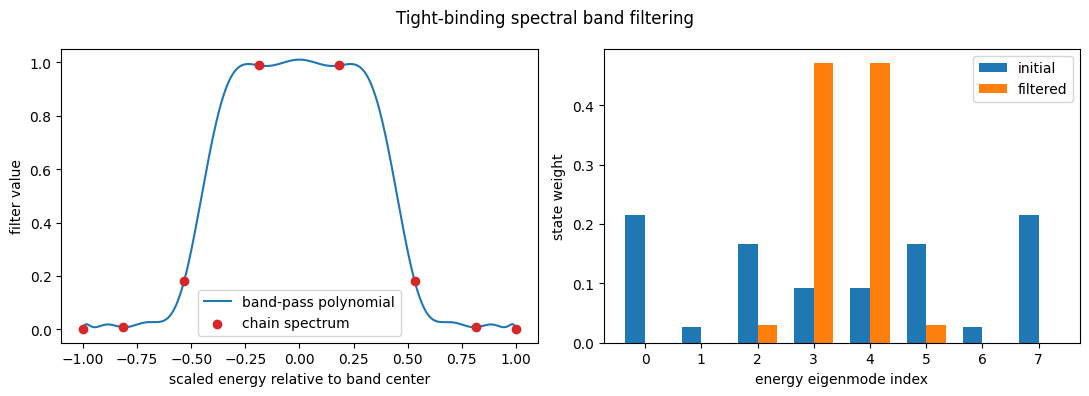

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

xs = np.linspace(-1, 1, 600)
axes[0].plot(xs, eval_polynomial(band_pass_coeffs, xs), label="band-pass polynomial")
axes[0].scatter(
    scaled_energies, band_weights, color="tab:red", zorder=3, label="chain spectrum"
)
axes[0].set_xlabel("scaled energy relative to band center")
axes[0].set_ylabel("filter value")
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()

width = 0.35
xpos = np.arange(n_sites)
axes[1].bar(xpos - width / 2, initial_mode_weights, width, label="initial")
axes[1].bar(xpos + width / 2, filtered_mode_weights, width, label="filtered")
axes[1].set_xlabel("energy eigenmode index")
axes[1].set_ylabel("state weight")
axes[1].legend()

fig.suptitle("Tight-binding spectral band filtering")
plt.tight_layout()
plt.show()

## What this demonstrates

The polynomial operates only on spectral values, so eigenvectors are preserved while selected energy components are amplified or suppressed. In a block-encoded setting, QSVT supplies the corresponding polynomial transform of the Hamiltonian.